<a href="https://colab.research.google.com/github/databyhuseyn/DeepLearning/blob/main/NGrams_NLP_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

--2026-05-20 16:00:28--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt’

names.txt           100%[===================>] 222.80K  --.-KB/s    in 0.03s   

2026-05-20 16:00:29 (8.47 MB/s) - ‘names.txt’ saved [228145/228145]



In [3]:
with open('names.txt', 'r') as f:
  names = f.read().splitlines()

In [4]:
len(names)

32033

In [5]:
vocab = sorted(list(set(''.join(names))))
stoi = {char:idx+1 for idx, char in enumerate(vocab)}
stoi['.'] = 0
itos = {v:k for k, v in stoi.items()}

In [6]:
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [7]:
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [8]:
vocab_size=len(stoi)

In [9]:
block_size = 3

def generate_dataset(names):
  X = []
  Y = []

  for name in names:
    context = [0] * block_size
    for char in name + '.':
      ix = stoi[char]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(names)
n1 = int(0.8 * len(names))
n2 = int(0.9 * len(names))

Xtr, Ytr = generate_dataset(names[:n1])
Xdev, Ydev = generate_dataset(names[n1:n2])
Xte, Yte = generate_dataset(names[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [10]:
n_emb = 10
n_hidden = 200

g = torch.Generator().manual_seed(7263186)
C = torch.randn((vocab_size, n_emb),             generator=g)
W1 = torch.randn((block_size * n_emb, n_hidden), generator=g) * (5/3) / ((block_size * n_emb) ** 0.5)
b1 = torch.randn(n_hidden,                       generator=g)
W2 = torch.randn((n_hidden, vocab_size),         generator=g)
b2 = torch.randn(vocab_size,                     generator=g)

bngain = torch.zeros((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.zeros((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(parameter.nelement() for parameter in parameters))
for p in parameters:
  p.requires_grad = True

12297


In [12]:
max_steps = 200_000
batch_size = 32
lossi = []
# lr = 1e-3
eps = 1e-7

for i in range(max_steps):

  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix]

  emb = C[Xb]
  embcat = emb.view(emb.shape[0], -1)

  hpreact = embcat @ W1 + b1
  ###
  # BATCHNORM
  bnmeani = hpreact.mean(dim=0, keepdim=True)
  bnstdi = hpreact.std(dim=0, keepdim=True)
  hpreact = bngain * ((hpreact - bnmeani) / (bnstdi + eps)) + bnbias
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  ###

  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Yb)
  lossi.append(loss.item())

  # backward pass
  for parameter in parameters:
    parameter.grad = None
  loss.backward()

  # LR Decay
  lr = 1e-3 if i < 100_000 else 1e-4
  for p in parameters:
    p.data -= lr * p.grad

  if i % 10_000 == 0:
    print(f'Step {i:.7d}/{max_steps:.7d}, Loss: {loss.item():.5f}')


3.2725651264190674
2.7481155395507812
2.9048447608947754
2.822265148162842
3.1366207599639893
2.788029670715332
2.6086063385009766
2.4630255699157715
2.805542230606079
2.6657679080963135
2.661635398864746
2.923710346221924
2.6061973571777344
2.2258098125457764
2.717179775238037
2.5636963844299316
2.558105945587158
2.3764946460723877
2.433316707611084
2.8990986347198486
2.8484678268432617
3.125446081161499
2.632059097290039
2.8418128490448
2.9234883785247803
2.5327510833740234
2.7115273475646973
2.632875680923462
2.590012550354004
2.834458589553833
2.520780086517334
2.376187324523926
2.4929182529449463
2.8689124584198
2.673518657684326
2.4934885501861572
2.53770112991333
2.5352632999420166
2.978118419647217
2.787189245223999
2.3301517963409424
2.4776649475097656
2.424772262573242
2.2559516429901123
2.185680389404297
2.7032957077026367
2.405017614364624
2.698286294937134
2.385244607925415
2.2823104858398438
2.575902223587036
2.6379613876342773
2.2383530139923096
2.3549041748046875
2.9762

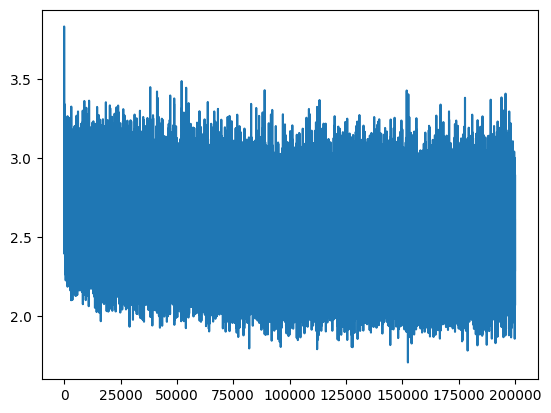

In [13]:
plt.plot(range(max_steps), lossi)

In [14]:
untrained_expeced_loss = -torch.log(torch.tensor(1/vocab_size))
untrained_expeced_loss

tensor(3.2958)

In [17]:
@torch.no_grad()
def split_loss(split):
  """
  `split`: this parameter can be `('train', 'val', 'test')`
  """
  X, Y = {
      'train': (Xtr, Ytr),
      'val': (Xdev, Ydev),
      'test': (Xte, Yte)
  }[split]

  emb = C[X]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # hpreact = bngain * ((hpreact - hpreact.mean(dim=0, keepdim=True)) / (hpreact.std(dim=0, keepdim=True) + eps)) + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Y)

  print(f'Split: {split}, Loss: {loss.item()}')

In [18]:
split_loss('train')
split_loss('val')
split_loss('test')

Split: train, Loss: 2.4394288063049316
Split: val, Loss: 2.437082290649414
Split: test, Loss: 2.437626838684082
